# Projeto Final — Análise Exploratória de Dados (Olist)
## Grupo: Gustavo Pires Bogéa / Haroé xxxx / Hélio xxxx

## 1. Apresentação da Base e Perguntas de Negócio

### 1.1. Origem dos Dados

Os dados foram extraídos do dataset público do **Olist** no Kaggle, cobrindo o e-commerce brasileiro. A combinação dessas tabelas permite mapear desde a realização da compra até a entrega do pedido e a avaliação final feita pelo cliente.

Bases originais utilizadas
a. Base de Clientes: 'df_customers'
b. Base de Perdas: 'df_orders'
c. Base de Itens de Pedidos: 'df_itens'
d. Base de Pagamentos: 'df_payments'
e. Base de Reavaliação: 'df_reviews'
f. Base de Produtos: 'df_products'
g. Base de Categorias de produto: 'df_categories'

Bases derivadas
a. Base de Pedidos de Clientes: 'df_orders_customers' - junção das bases originais 'df_orders' com 'df_customers' relacionando clientes e pedidos.
b. Base de Pedidos de clientes e Itens: 'df_entrega' - junção da base derivada 'df_orders_customers' e com a base original 'df_itens, incluindo a relação por itens. 
c. Base de Itens e Produtos: 'df_itens_produtos' - junção das bases originais 'df_itens' e 'df_products' VERIFICAR SE A BASE DE PRODUTOS ESTÁ SENDO UTILIZADA, SE VALE A PENA MANTER!

#### 1.1.1 Base de Clientes ('df_customers')
Armazena informações cadastrais e geográficas dos compradores.
* **`customer_id`**: Chave gerada a cada pedido (ligação à tabela de pedidos).
* **`customer_unique_id`**: Identificador único do cliente (utilizado para analisar compras recorrentes).
* **`customer_zip_code_prefix`**: Código postal do cliente.
* **`customer_city`**: Cidade de residência do cliente.
* **`customer_state`**: Sigla do Estado (UF) do cliente.

#### 1.1.2 Base de Pedidos ('df_orders')
Centraliza o ciclo de vida e a esteira de status de cada transação.
* **`order_id`**: Identificador único do pedido.
* **`customer_id`**: Chave de ligação com a tabela de clientes.
* **`order_status`**: Status atual do pedido (`delivered`, `canceled`, etc.).
* **`order_purchase_timestamp`**: Data e hora da realização da compra.
* **`order_delivered_customer_date`**: Data e hora da entrega efetiva ao cliente.
* **`order_estimated_delivery_date`**: Data estimada de entrega.

#### 1.1.3 Base de Itens do Pedido ('df_items')
Detalha os produtos e valores associados a cada item contido num pedido.
* **`order_id`**: Identificador do pedido.
* **`order_item_id`**: Sequencial do item dentro do pedido (ex: 1, 2, 3).
* **`product_id`**: Identificador único do produto vendido.
* **`seller_id`**: Identificador único do vendedor.
* **`price`**: Preço unitário do produto (em R$).
* **`freight_value`**: Valor do frete associado ao item (em R$).

#### 1.1.4 Base de Pagamentos ('df_payments')
Registra os métodos financeiros e condições de parcelamento.
* **`order_id`**: Identificador do pedido.
* **`payment_type`**: Método de pagamento utilizado (`credit_card`, `boleto`, `voucher`, `debit_card`).
* **`payment_installments`**: Número de parcelas escolhidas.
* **`payment_value`**: Valor total pago na transação.

#### 1.1.5 Base de Avaliações ('df_reviews')
Contém os feedbacks diretos deixados pelos clientes após a entrega.
* **`review_id`**: Identificador único da avaliação.
* **`order_id`**: Identificador do pedido avaliado.
* **`review_score`**: Nota atribuída pelo cliente (1 a 5).
* **`review_comment_message`**: Comentário/feedback em texto do cliente.

#### 1.1.6 Base de Produtos ('df_products')
Contém as características físicas e a categoria de cada produto listado na plataforma.
* **`product_id`**: Identificador único do produto.
* **`product_category_name`**: Nome da categoria do produto em português.
* **`product_weight_g`**: Peso do produto em gramas.
* **`product_length_cm` / `product_height_cm` / `product_width_cm`**: Dimensões físicas do produto.

#### 1.1.7 Base de Categorias ('df_categories')
Tabela auxiliar de mapeamento e tradução das categorias de produtos.
* **`product_category_name`**: Nome original da categoria em português.
* **`product_category_name_english`**: Nome traduzido da categoria para inglês.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura das 7 bases de dados
df_customers = pd.read_csv('../dados/olist_customers_dataset.csv')
df_orders = pd.read_csv('../dados/olist_orders_dataset.csv')
df_items = pd.read_csv('../dados/olist_order_items_dataset.csv')
df_payments = pd.read_csv('../dados/olist_order_payments_dataset.csv')
df_reviews = pd.read_csv('../dados/olist_order_reviews_dataset.csv')
df_products = pd.read_csv('../dados/olist_products_dataset.csv')
df_categories = pd.read_csv('../dados/product_category_name_translation.csv')

print("Todas as 7 bases foram carregadas com sucesso!")

Todas as 7 bases foram carregadas com sucesso!


### 1.2. PERGUNTAS DO NEGÓCIO
1. **Prazos e Frete:** Qual a relação entre o custo do frete e o tempo real de entrega entre os diferentes estados?
2. **Meios de Pagamento e Ticket:** Como o valor médio do pedido varia em função do tipo de pagamento e do parcelamento?
3. **Outliers de Frete:** Qual o comportamento do status dos pedidos e tempo de entrega ao longo do tempo?
4. **Recorrência:** Clientes recorrentes possuem comportamento de compra diferente dos clientes pontuais?

### 1.3. Estrutura e Granularidade das Bases
Antes de realizar os cruzamentos entre as tabelas, vamos verificar a estrutura e a granularidade de cada base. Isso é importante porque uma mesma informação pode aparecer várias vezes em algumas tabelas. Por exemplo, um pedido pode possuir vários itens e também vários pagamentos. Portanto, em vez de criar um único DataFrame com todas as tabelas, construiremos DataFrames específicos de acordo com cada pergunta de negócio, evitando a duplicação de registros e a distorção das métricas.

In [ ]:
# Tradução das categorias dos produtos #A TABELA DE PRODUTOS ESTÁ SENDO UTILIZADA NA BASE?
df_products = df_products.merge(
    df_categories,
    on='product_category_name',
    how='left'
)

print("Categorias dos produtos traduzidas.")

Categorias dos produtos traduzidas.


#### 1.3.1. Verificação da estrutura das bases

Primeiro, vamos verificar a quantidade de linhas e colunas de cada tabela. Essa informação ajuda a identificar o tamanho das bases e, principalmente, perceber que elas possuem diferentes níveis de granularidade.

In [4]:
print("orders:", df_orders.shape)
print("customers:", df_customers.shape)
print("items:", df_items.shape)
print("payments:", df_payments.shape)
print("products:", df_products.shape)
print("reviews:", df_reviews.shape)
print("categories:", df_categories.shape)

orders: (99441, 8)
customers: (99441, 5)
items: (112650, 7)
payments: (103886, 5)
products: (32951, 10)
reviews: (99224, 7)
categories: (71, 2)


#### 1.3.2. Verificação da granularidade

Agora vamos verificar se order_id é único em cada tabela. Em orders, esperamos um registro por pedido. Já em items e payments, um mesmo pedido pode aparecer várias vezes, pois um pedido pode conter vários itens e pode possuir mais de um pagamento.

In [5]:
print("order_id único em orders:",
      df_orders['order_id'].is_unique)

print("order_id único em items:",
      df_items['order_id'].is_unique)

print("order_id único em payments:",
      df_payments['order_id'].is_unique)

order_id único em orders: True
order_id único em items: False
order_id único em payments: False


Interpretação: A tabela orders possui um registro único para cada pedido. Já items e payments possuem múltiplos registros para um mesmo order_id. Por isso, juntar essas tabelas diretamente poderia multiplicar registros quando um pedido possui vários itens e vários pagamentos. Para evitar esse problema, as tabelas serão combinadas de acordo com a necessidade de cada análise.

#### 1.3.3 Construção dos DataFrames para análise

Como as tabelas possuem diferentes níveis de granularidade, não utilizaremos um único DataFrame com todas as informações.

Os cruzamentos serão realizados de acordo com cada pergunta de negócio, preservando a granularidade adequada para cada análise.

##### 1.3.3.1. Pedidos e clientes

Primeiro, vamos relacionar os pedidos aos seus respectivos clientes.

A tabela `orders` possui um registro por pedido e `customers` possui as informações do cliente associado ao pedido. Portanto, esperamos uma relação de um para um entre essas duas tabelas por `customer_id`.

In [6]:
df_orders_customers = df_orders.merge(
    df_customers,
    on='customer_id',
    how='left',
    validate='one_to_one'
)

print("Orders:", df_orders.shape)
print("Orders + Customers:", df_orders_customers.shape)

Orders: (99441, 8)
Orders + Customers: (99441, 12)


**Interpretação:** O primeiro cruzamento entre `orders` e `customers` manteve as 99.441 linhas da tabela de pedidos. Isso confirma que o relacionamento utilizado preservou a granularidade de um registro por pedido.

##### 1.3.3.2. Pedidos, clientes e itens

Agora adicionaremos os itens dos pedidos. Diferentemente da relação anterior, um pedido pode possuir vários itens. Portanto, esperamos uma relação de um para muitos (`one-to-many`).

Após esse cruzamento, a granularidade do DataFrame passa de **um registro por pedido** para **um registro por item do pedido**.

In [7]:
df_entrega = df_orders_customers.merge(
    df_items,
    on='order_id',
    how='left',
    validate='one_to_many'
)

print("Orders + Customers:", df_orders_customers.shape)
print("Orders + Customers + Items:", df_entrega.shape)

Orders + Customers: (99441, 12)
Orders + Customers + Items: (113425, 18)


**Interpretação:** Após adicionar a tabela `items`, o número de registros aumentou de 99.441 para 113.425. Isso ocorre porque um mesmo pedido pode conter vários itens. Portanto, o DataFrame `df_entrega` passa a ter como granularidade um registro por item do pedido, e não mais um registro por pedido.

In [8]:
df_entrega[['order_id', 'product_id', 'price', 'freight_value']].head(10)

,order_id,product_id,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72
5,a4591c265e18cb1dcee52889e2d8acc3,060cb19345d90064d1015407193c233d,147.90,27.36
6,136cce7faa42fdb2cefd53fdc79a6098,a1804276d9941ac0733cfd409f5206eb,49.90,16.05
7,6514b8ad8028c9f2cc2374ded245783f,4520766ec412348b8d4caa5e8a18c464,59.99,15.17
8,76c6e866289321a7c93b82b54852dc33,ac1789e492dcd698c5c10b97a671243a,19.90,16.05
9,e69bfb5eb88e0ed6a785585b27e16dbf,9a78fb9862b10749a117f7fc3c31f051,149.99,19.77


### Verificação de um pedido com múltiplos itens

Para visualizar na prática a mudança de granularidade, vamos identificar um pedido que possui vários itens e observar como ele aparece no DataFrame após o cruzamento.

In [9]:
pedido_exemplo = (
    df_entrega.groupby('order_id')
    .size()
    .sort_values(ascending=False)
    .index[0]
)

print("Pedido escolhido:", pedido_exemplo)

df_entrega[
    df_entrega['order_id'] == pedido_exemplo
][['order_id', 'product_id', 'price', 'freight_value']]

Pedido escolhido: 8272b63d03f5f79c56e9e4120aec44ef


,order_id,product_id,price,freight_value
101222,8272b63d03f5f79c56e9e4120aec44ef,270516a3f41dc035aa87d220228f844c,1.2,7.89
101223,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101224,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101225,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101226,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101227,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101228,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101229,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101230,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101231,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89


##### 1.3.3.3. Itens e produtos

Para complementar as informações dos itens, vamos relacioná-los aos dados dos produtos por meio de `product_id`.

A tabela `order_items` pode possuir vários registros para o mesmo produto, pois um produto pode ser vendido em diferentes pedidos. Já a tabela `products` possui um registro por produto.

Portanto, esperamos uma relação de muitos para um (`many-to-one`).

In [10]:
df_itens_produtos = df_items.merge(
    df_products,
    on='product_id',
    how='left',
    validate='many_to_one'
)

print("Items:", df_items.shape)
print("Items + Products:", df_itens_produtos.shape)

Items: (112650, 7)
Items + Products: (112650, 16)


O cruzamento manteve a quantidade de registros porque cada item está associado a um único produto. A relação `many-to-one` foi validada com sucesso.

## 2. Diagnóstico da Qualidade dos Dados

Antes de realizar as análises, vamos verificar a qualidade e a estrutura dos dados utilizados.

Como cada pergunta de negócio utiliza DataFrames com diferentes granularidades, o diagnóstico será realizado considerando a base correspondente a cada análise.

Nesta primeira etapa, vamos analisar o `df_entrega`, utilizado nas análises relacionadas a prazo, frete e estado.

### 2.1. Dimensões, tipos e uso de memória

In [11]:
df_entrega.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  113425 non-null  str    
 8   customer_unique_id             113425 non-null  str    
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  str    
 11  customer_state                 113425 non-null  str    
 12  order_item_id                  112650 non

**Interpretação:** O DataFrame `df_entrega` possui 113.425 registros e 18 colunas, com aproximadamente 15,6 MB de uso de memória. A maior parte das colunas está no formato `object`, incluindo as datas, que posteriormente poderão ser convertidas para o formato `datetime` para permitir cálculos relacionados a prazos de entrega.

Também foram identificados valores ausentes em algumas colunas, principalmente nas informações relacionadas à aprovação e às datas de entrega. Esses valores serão investigados na próxima etapa do diagnóstico antes de definir qualquer estratégia de tratamento.

### 2.2. Valores ausentes

In [12]:
missing = pd.DataFrame({
    'quantidade': df_entrega.isna().sum(),
    'percentual': (df_entrega.isna().mean() * 100).round(2)
})

missing = missing[missing['quantidade'] > 0].sort_values(
    'percentual',
    ascending=False
)

missing

,quantidade,percentual
order_delivered_customer_date,3229,2.85
order_delivered_carrier_date,1968,1.74
order_item_id,775,0.68
product_id,775,0.68
seller_id,775,0.68
shipping_limit_date,775,0.68
price,775,0.68
freight_value,775,0.68
order_approved_at,161,0.14


#### 2.2.1. Investigação dos valores ausentes em order_items

As colunas relacionadas aos itens apresentam exatamente a mesma quantidade de valores ausentes. Vamos verificar se esses registros correspondem a pedidos que não possuem informações na tabela `order_items`.

Essa verificação é importante para diferenciar valores ausentes originados nos dados de origem daqueles que surgiram como consequência do cruzamento entre as tabelas.

In [13]:
colunas_items = [
    'order_item_id',
    'product_id',
    'seller_id',
    'shipping_limit_date',
    'price',
    'freight_value'
]

df_entrega[df_entrega['order_item_id'].isna()][colunas_items].head()

,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
306,NaN,NaN,NaN,NaN,NaN,NaN
671,NaN,NaN,NaN,NaN,NaN,NaN
791,NaN,NaN,NaN,NaN,NaN,NaN
850,NaN,NaN,NaN,NaN,NaN,NaN
1294,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.2.2. Investigação dos valores ausentes nas datas do pedido

As datas relacionadas ao processo de entrega apresentam valores ausentes em diferentes proporções. Antes de definir qualquer tratamento, vamos verificar a situação dos pedidos e identificar se os valores ausentes estão relacionados ao status do pedido.

In [14]:
df_entrega['order_status'].value_counts(dropna=False)

order_status
delivered      110197
shipped          1186
canceled          706
unavailable       610
invoiced          361
processing        357
created             5
approved            3
Name: count, dtype: int64

#### 2.2.3. Relação entre status do pedido e datas ausentes

Como `df_entrega` possui granularidade de item, a análise das datas e do status será realizada utilizando `df_orders_customers`, que possui uma linha por pedido.

Dessa forma, cada pedido será contabilizado uma única vez, evitando que pedidos com vários itens tenham peso maior no diagnóstico.

In [15]:
status_datas = df_orders_customers.groupby('order_status').agg(
    total_pedidos=('order_id', 'count'),
    sem_data_transportadora=('order_delivered_carrier_date', lambda x: x.isna().sum()),
    sem_data_entrega=('order_delivered_customer_date', lambda x: x.isna().sum())
)

status_datas

,total_pedidos,sem_data_transportadora,sem_data_entrega
order_status,,,
approved,2,2,2
canceled,625,550,619
created,5,5,5
delivered,96478,2,8
invoiced,314,314,314
processing,301,301,301
shipped,1107,0,1107
unavailable,609,609,609


#### 2.2.4. Investigação dos pedidos entregues sem data de entrega

Embora a maioria dos pedidos com status `delivered` possua as datas de entrega preenchidas, foram identificados 8 pedidos sem `order_delivered_customer_date`.

Vamos verificar esses registros antes de definir o tratamento, pois eles não poderão ser utilizados no cálculo do prazo real de entrega enquanto a data estiver ausente.

In [16]:
df_orders_customers[
    (df_orders_customers['order_status'] == 'delivered') &
    (df_orders_customers['order_delivered_customer_date'].isna())
][[
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


**Interpretação:** Foram identificados 8 pedidos com status `delivered` que não possuem a data efetiva de entrega ao cliente. Como essa informação não pode ser determinada de forma confiável a partir dos dados disponíveis, esses valores não serão preenchidos artificialmente.

Para a análise de prazo real de entrega, serão considerados posteriormente apenas os pedidos que possuam as datas necessárias para o cálculo. Dessa forma, preservamos os dados originais e evitamos introduzir informações estimadas sem justificativa.

### 2.3. Registros duplicados

Como `df_orders_customers` possui uma linha por pedido, vamos verificar se existem registros completamente duplicados nessa base.

Essa verificação é importante para identificar possíveis repetições dos mesmos registros antes das etapas de transformação e análise.

In [17]:
duplicados_orders = df_orders_customers.duplicated().sum()

print("Registros duplicados:", duplicados_orders)

Registros duplicados: 0


**Interpretação:** Não foram identificados registros completamente duplicados em `df_orders_customers`. Portanto, não será necessário realizar uma remoção de duplicidades nessa base.

### 2.4. Verificação de categorias inconsistentes

Vamos verificar as categorias existentes em `order_status` para identificar possíveis diferenças de grafia, espaços ou outras inconsistências que possam representar a mesma categoria.

In [18]:
df_orders_customers['order_status'].value_counts(dropna=False)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

**Interpretação:** As categorias de `order_status` apresentam nomenclatura padronizada, sem diferenças aparentes de grafia, capitalização ou espaços que indiquem categorias duplicadas. Portanto, não é necessário realizar tratamento de padronização nessa variável.

#### 2.4.1. Verificação das categorias de estado

Como o estado do cliente será utilizado nas análises de frete e prazo, vamos verificar as categorias presentes em `customer_state` e identificar possíveis valores inconsistentes.

In [19]:
df_orders_customers['customer_state'].value_counts(dropna=False)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

#### 2.4.2. Verificação de espaços e caps

Além da inspeção das categorias, vamos verificar se existem valores que seriam alterados ao remover espaços ou padronizar as letras para maiúsculas.

In [20]:
estados_inconsistentes = df_orders_customers[
    df_orders_customers['customer_state'] !=
    df_orders_customers['customer_state'].str.strip().str.upper()
][['customer_state']]

estados_inconsistentes.drop_duplicates()

,customer_state


### 2.5. Verificação de valores inválidos

Nesta etapa, vamos verificar se existem valores numéricos que não são compatíveis com o significado das variáveis utilizadas na análise.

Como `price` representa o preço do item e `freight_value` representa o valor do frete, valores negativos seriam inconsistentes com essas definições.

In [21]:
valores_invalidos = {
    'price_negativo': (df_entrega['price'] < 0).sum(),
    'freight_negativo': (df_entrega['freight_value'] < 0).sum()
}

pd.Series(valores_invalidos)

price_negativo      0
freight_negativo    0
dtype: int64

**Interpretação:** Não foram identificados valores negativos nas variáveis `price` e `freight_value`. Portanto, não foi identificado, nesta verificação, nenhum valor incompatível com o significado dessas variáveis.

### 2.6. Identificação de Outliers

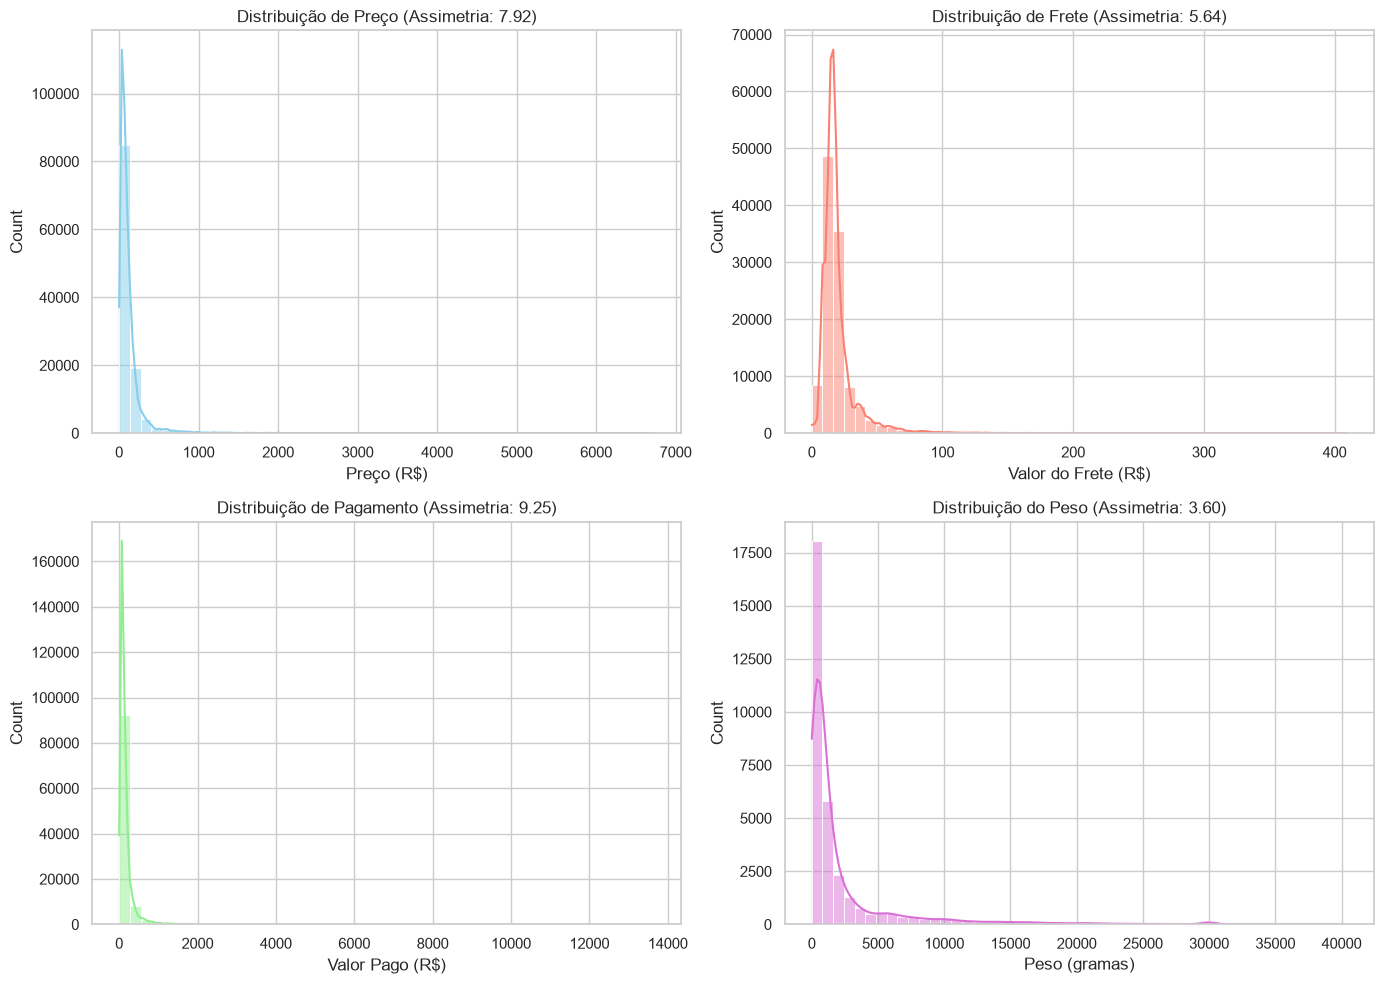

=== APLICAÇÃO DO MÉTODO IQR PARA VARIÁVEIS ASSIMÉTRICAS ===

--- Outliers de Frete Agrupados por Estado (Top 10 UFs com mais anomalias) ---
                Total_Registros     Q1     Q3  Limite_Sup_IQR  Qtd_Outliers  \
customer_state                                                                
SP                      47449.0   9.34  16.25           26.62        3404.0   
RJ                      14579.0  15.16  21.12           30.06        1580.0   
MG                      13129.0  15.10  21.35           30.73        1088.0   
PR                       5740.0  15.10  19.94           27.20         654.0   
RS                       6235.0  15.46  21.66           30.97         643.0   
SC                       4176.0  15.23  21.10           29.90         430.0   
BA                       3799.0  17.25  27.28           42.32         401.0   
GO                       2333.0  15.44  22.93           34.16         287.0   
DF                       2406.0  15.23  21.68           31.35         

In [42]:
# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# =========================================================
# 2.2.1 VERIFICAÇÃO DE NORMALIDADE (HISTOGRAMAS E ASSIMETRIA)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição do Preço dos Produtos (df_items)
sns.histplot(df_items['price'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title(f"Distribuição de Preço (Assimetria: {df_items['price'].skew():.2f})")
axes[0, 0].set_xlabel("Preço (R$)")

# 2. Distribuição do Valor do Frete (df_items)
sns.histplot(df_items['freight_value'], bins=50, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title(f"Distribuição de Frete (Assimetria: {df_items['freight_value'].skew():.2f})")
axes[0, 1].set_xlabel("Valor do Frete (R$)")

# 3. Distribuição do Valor do Pagamento (df_payments)
sns.histplot(df_payments['payment_value'], bins=50, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title(f"Distribuição de Pagamento (Assimetria: {df_payments['payment_value'].skew():.2f})")
axes[1, 0].set_xlabel("Valor Pago (R$)")

# 4. Distribuição do Peso do Produto (df_products)
sns.histplot(df_products['product_weight_g'].dropna(), bins=50, kde=True, ax=axes[1, 1], color='orchid')
axes[1, 1].set_title(f"Distribuição do Peso (Assimetria: {df_products['product_weight_g'].skew():.2f})")
axes[1, 1].set_xlabel("Peso (gramas)")

plt.tight_layout()
plt.show()

# =========================================================
# 2.2.2 APLICAÇÃO DO MÉTODO IQR (ADEQUADO PARA DISTRIBUIÇÕES ASSIMÉTRICAS)
# =========================================================
print("=== APLICAÇÃO DO MÉTODO IQR PARA VARIÁVEIS ASSIMÉTRICAS ===")

# A) Outliers de Frete por Grupo de Comparação (Estado do Cliente)
df_items_cust = df_items.merge(df_orders[['order_id', 'customer_id']], on='order_id')
df_items_cust = df_items_cust.merge(df_customers[['customer_id', 'customer_state']], on='customer_id')

def detecta_outliers_iqr_grupo(grupo, coluna):
    q1 = grupo[coluna].quantile(0.25)
    q3 = grupo[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    outliers = grupo[grupo[coluna] > limite_superior]
    
    return pd.Series({
        'Total_Registros': len(grupo),
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'Limite_Sup_IQR': round(limite_superior, 2),
        'Qtd_Outliers': len(outliers),
        '%_Outliers': round((len(outliers) / len(grupo)) * 100, 2)
    })

print("\n--- Outliers de Frete Agrupados por Estado (Top 10 UFs com mais anomalias) ---")
resumo_frete_estado = df_items_cust.groupby('customer_state').apply(detecta_outliers_iqr_grupo, coluna='freight_value').sort_values(by='Qtd_Outliers', ascending=False)
print(resumo_frete_estado.head(10))

# B) Outliers Globais via IQR para Preço e Valor de Pagamento
def resumo_iqr_global(df, coluna, nome_base):
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    outliers = df[df[coluna] > lim_sup]
    print(f"\n--- Outliers Globais via IQR: Base {nome_base} ({coluna}) ---")
    print(f"Q1: R$ {q1:.2f} | Q3: R$ {q3:.2f} | Limite Superior IQR: R$ {lim_sup:.2f}")
    print(f"Registros acima do limite: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

resumo_iqr_global(df_items, 'price', 'df_items')
resumo_iqr_global(df_payments, 'payment_value', 'df_payments')

### 2.6.1 Justificativa Metodológica e Relatório de Outliers

#### Teste de Normalidade e Escolha do Método
* **Diagnóstico de Distribuição:** A análise visual dos histogramas aliada ao cálculo do coeficiente de assimetria (*skewness*) confirma que as variáveis numéricas das bases (`price`, `freight_value`, `payment_value` e `product_weight_g`) **não seguem uma distribuição normal** (apresentam assimetria positiva acentuada com cauda longa à direita).
* **Definição da Métrica:** Em distribuições não normais/assimétricas, a média e o desvio padrão são severamente distorcidos por valores extremos, inviabilizando o uso do Z-Score. Desta forma, o método do **Intervalo Interquartil (IQR)** foi selecionado como a abordagem estatística adequada, definindo os limites como:
  $$\text{Limite Superior} = Q_3 + 1.5 \times \text{IQR}$$

#### Contextualização por Grupo de Comparação (Frete por Estado)
* A avaliação do valor do frete foi executada agrupando as transações pelo Estado de destino do cliente (`customer_state`).
* **Justificativa:** Custos logísticos no Brasil variam drasticamente conforme a distância geográfica dos centros de distribuição (localizados majoritariamente no Sudeste). Definir um único limite de frete global classificaria erroneamente fretes normais da Região Norte como *outliers*. O agrupamento por UF garante um diagnóstico justo dentro da realidade de cada mercado regional.

#### Interpretação Negocial das Anomalias
* Os *outliers* identificados em preço e valor pago não representam erros de digitação na base de dados, mas sim transações reais de produtos de elevado valor unitário ou compras em lote.

### 2.7. Análise de distribuição das variáveis quantitativas SERÁ NECESSÁRIO. ACHO QUE PODE SER EXCLUÍDA!


 📊 ANALISANDO DISTRIBUIÇÕES: df_orders_customers


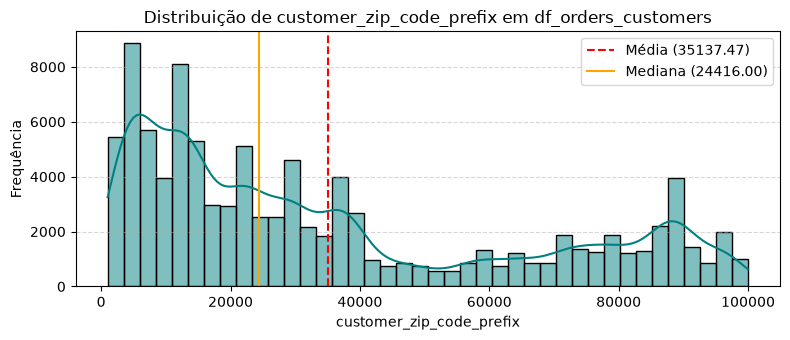

,Coluna,Média,Mediana,Skewness,Kurtosis,Classificação,Outliers (IQR),Outliers (Z-Score)
0,customer_zip_code_prefix,35137.47,24416.0,0.78,-0.79,Assimétrica à Direita (Cauda Longa),0 (0.0%),0 (0.0%)



 📊 ANALISANDO DISTRIBUIÇÕES: df_items


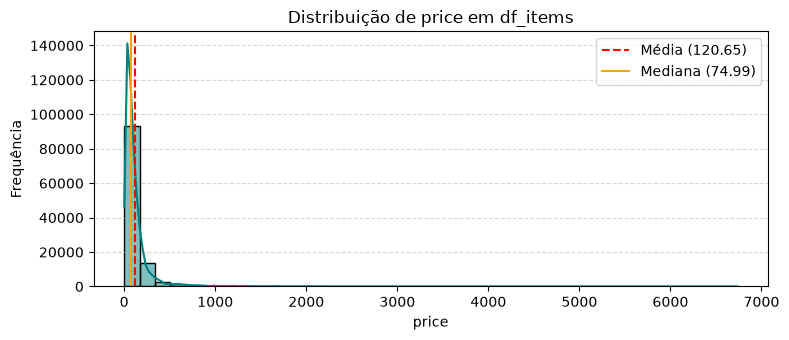

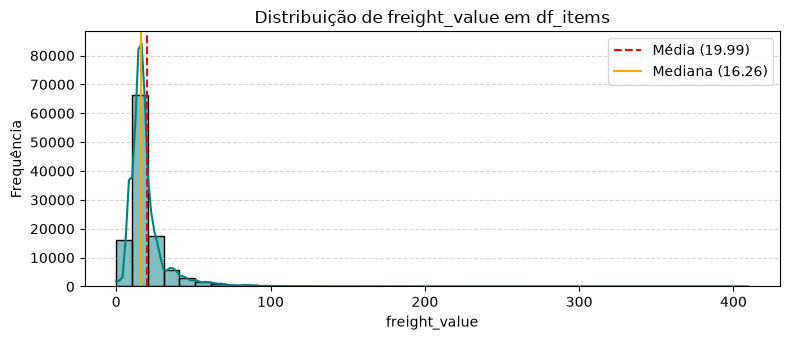

,Coluna,Média,Mediana,Skewness,Kurtosis,Classificação,Outliers (IQR),Outliers (Z-Score)
0,price,120.65,74.99,7.92,120.83,Assimétrica à Direita (Cauda Longa),"8,427 (7.5%)","1,966 (1.7%)"
1,freight_value,19.99,16.26,5.64,59.79,Assimétrica à Direita (Cauda Longa),"12,134 (10.8%)","2,041 (1.8%)"



 📊 ANALISANDO DISTRIBUIÇÕES: df_payments


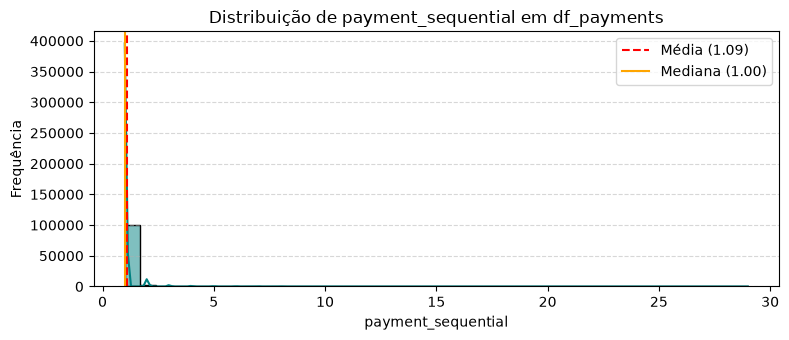

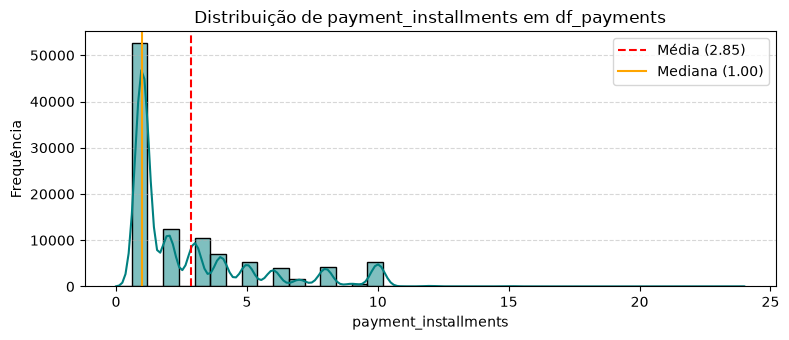

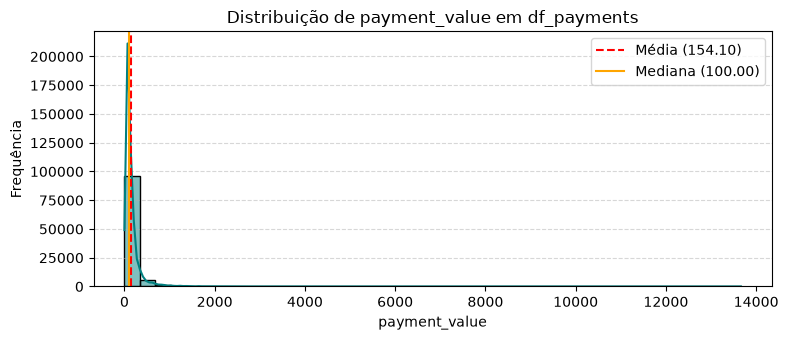

,Coluna,Média,Mediana,Skewness,Kurtosis,Classificação,Outliers (IQR),Outliers (Z-Score)
0,payment_sequential,1.09,1.0,16.18,370.59,Assimétrica à Direita (Cauda Longa),"4,526 (4.4%)",906 (0.9%)
1,payment_installments,2.85,1.0,1.66,2.55,Assimétrica à Direita (Cauda Longa),"6,313 (6.1%)",341 (0.3%)
2,payment_value,154.10,100.0,9.25,241.83,Assimétrica à Direita (Cauda Longa),"7,981 (7.7%)","1,803 (1.7%)"



 📊 ANALISANDO DISTRIBUIÇÕES: df_entrega


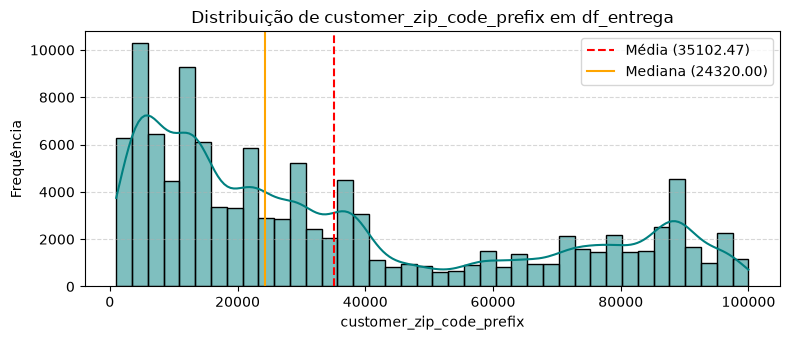

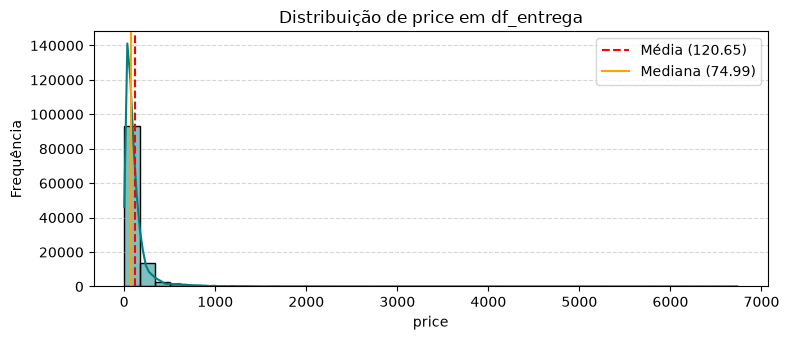

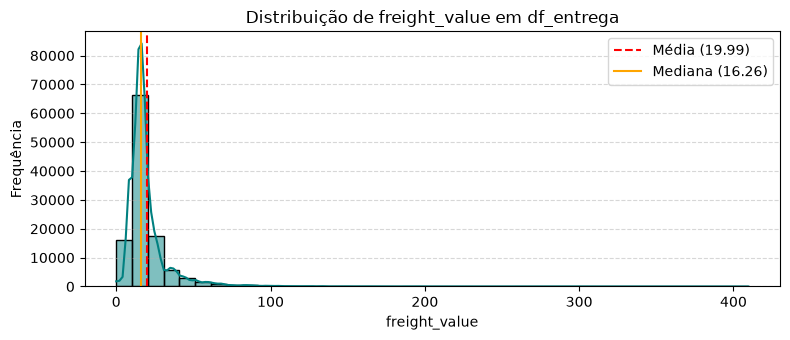

,Coluna,Média,Mediana,Skewness,Kurtosis,Classificação,Outliers (IQR),Outliers (Z-Score)
0,customer_zip_code_prefix,35102.47,24320.00,0.78,-0.79,Assimétrica à Direita (Cauda Longa),0 (0.0%),0 (0.0%)
1,price,120.65,74.99,7.92,120.83,Assimétrica à Direita (Cauda Longa),"8,427 (7.5%)","1,966 (1.7%)"
2,freight_value,19.99,16.26,5.64,59.79,Assimétrica à Direita (Cauda Longa),"12,134 (10.8%)","2,041 (1.8%)"


In [ ]:
# # ==============================================================================
# 2.7. Análise de Distribuição e Outliers das Variáveis Quantitativas
# Métodos: Skewness, Kurtosis, IQR, Z-Score (NumPy) e Histogramas
# ==============================================================================

# Dicionário com os DataFrames principais mapeados pelo grupo
dataframes_projeto = {
    'df_orders_customers': df_orders_customers,
    'df_items': df_items,
    'df_payments': df_payments,
    'df_entrega': df_entrega
}

for nome_df, df_atual in dataframes_projeto.items():
    print(f"\n==================================================================")
    print(f" 📊 ANALISANDO DISTRIBUIÇÕES: {nome_df}")
    print(f"==================================================================")
    
    # Seleção das colunas numéricas (excluindo IDs sequenciais/códigos)
    colunas_numericas = df_atual.select_dtypes(include=["number"]).columns
    colunas_numericas = [c for c in colunas_numericas if not c.endswith('_id') and c != 'order_item_id']
    
    if len(colunas_numericas) == 0:
        print(f"Nenhuma coluna numérica contínua encontrada em {nome_df}.\n")
        continue

    dados_distribuicao = []

    for col in colunas_numericas:
        dados = df_atual[col].dropna()
        
        # 1. Cálculo de Assimetria (Skewness) e Curtose (Kurtosis)
        skew = dados.skew()
        kurt = dados.kurt()
        
        # Classificação baseada no Skewness
        if abs(skew) < 0.5:
            tipo_distribuicao = "Aproximadamente Normal"
        elif skew >= 0.5:
            tipo_distribuicao = "Assimétrica à Direita (Cauda Longa)"
        else:
            tipo_distribuicao = "Assimétrica à Esquerda"

        # 2. Cálculo do IQR
        q1 = dados.quantile(0.25)
        q3 = dados.quantile(0.75)
        iqr = q3 - q1
        outliers_iqr = ((dados < (q1 - 1.5 * iqr)) | (dados > (q3 + 1.5 * iqr))).sum()
        pct_iqr = (outliers_iqr / len(dados)) * 100

        # 3. Cálculo do Z-Score com NumPy
        vetor_dados = dados.values
        media_np = np.mean(vetor_dados)
        desvio_np = np.std(vetor_dados)
        outliers_z = np.sum(np.abs((vetor_dados - media_np) / desvio_np) > 3) if desvio_np > 0 else 0
        pct_z = (outliers_z / len(dados)) * 100

        # Armazena os resultados para exibição tabular
        dados_distribuicao.append({
            'Coluna': col,
            'Média': round(media_np, 2),
            'Mediana': round(dados.median(), 2),
            'Skewness': round(skew, 2),
            'Kurtosis': round(kurt, 2),
            'Classificação': tipo_distribuicao,
            'Outliers (IQR)': f"{outliers_iqr:,} ({pct_iqr:.1f}%)",
            'Outliers (Z-Score)': f"{outliers_z:,} ({pct_z:.1f}%)"
        })

        # 4. Histograma da Distribuição
        plt.figure(figsize=(8, 3.5))
        sns.histplot(dados, bins=40, kde=True, color='teal')
        plt.axvline(media_np, color='red', linestyle='--', linewidth=1.5, label=f'Média ({media_np:.2f})')
        plt.axvline(dados.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Mediana ({dados.median():.2f})')
        plt.title(f'Distribuição de {col} em {nome_df}')
        plt.xlabel(col)
        plt.ylabel('Frequência')
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    # Exibe a tabela com o resumo de assimetria e curtose para o DataFrame atual
    df_resumo = pd.DataFrame(dados_distribuicao)
    display(df_resumo)


📊 Gerando histogramas para: df_orders_customers


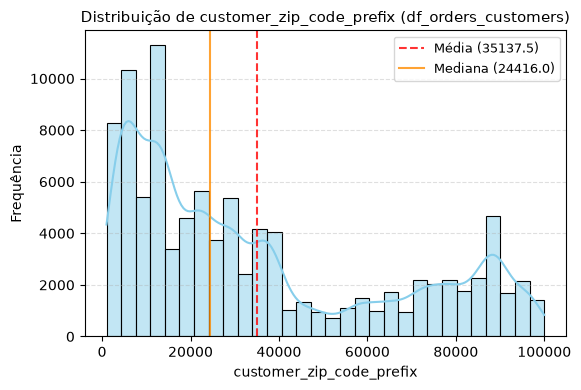


📊 Gerando histogramas para: df_items


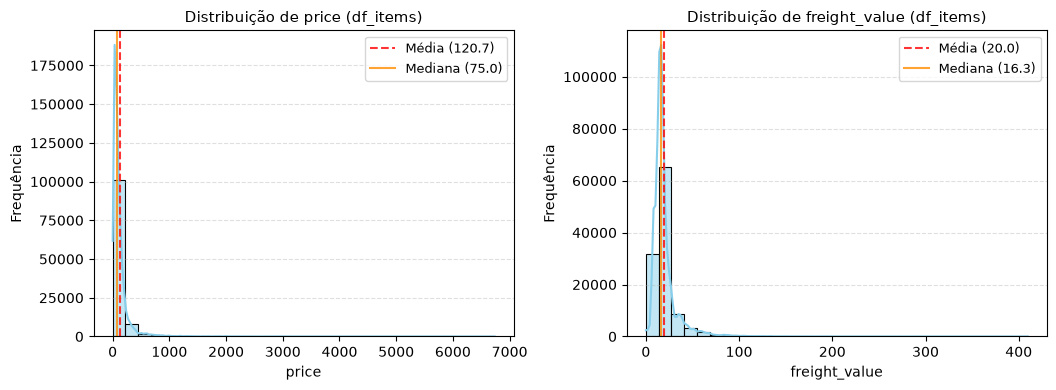


📊 Gerando histogramas para: df_payments


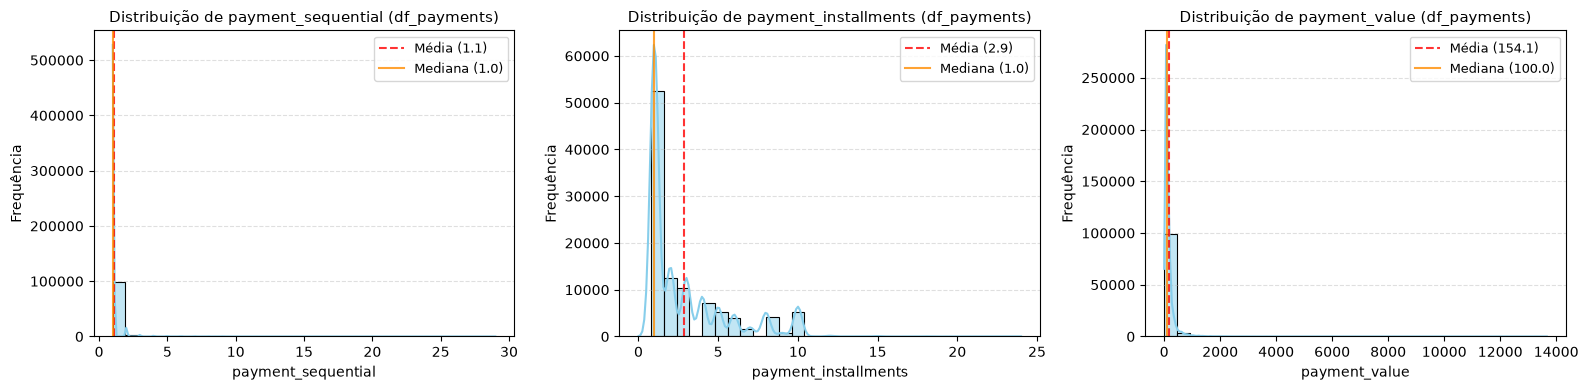


📊 Gerando histogramas para: df_entrega


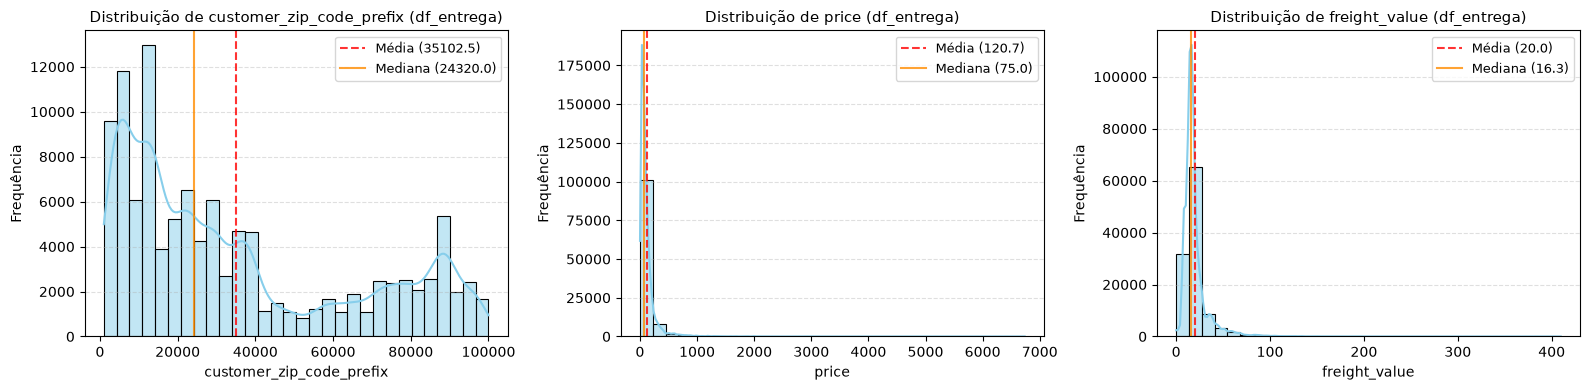

In [29]:
# ==============================================================================
# Plot dos histogramas com estimativa de densidade de kernel (KDE)
# Automatizado para todos os DataFrames do projeto
# ==============================================================================

# Dicionário com os DataFrames mapeados pelo grupo
dataframes_projeto = {
    'df_orders_customers': df_orders_customers,
    'df_items': df_items,
    'df_payments': df_payments,
    'df_entrega': df_entrega
}

for nome_df, df_atual in dataframes_projeto.items():
    # Seleção de colunas numéricas excluindo IDs e códigos sequenciais
    colunas_numericas = df_atual.select_dtypes(include=["number"]).columns
    colunas_numericas = [c for c in colunas_numericas if not c.endswith('_id') and c != 'order_item_id']
    
    if len(colunas_numericas) == 0:
        continue

    print(f"\n📊 Gerando histogramas para: {nome_df}")

    num_cols = len(colunas_numericas)
    cols_per_row = 3
    rows = (num_cols + cols_per_row - 1) // cols_per_row

    plt.figure(figsize=(16, 4 * rows))

    for i, col in enumerate(colunas_numericas, 1):
        plt.subplot(rows, cols_per_row, i)
        
        # Histograma com estimativa de densidade de kernel (KDE)
        sns.histplot(df_atual[col].dropna(), kde=True, bins=30, color='skyblue')
        
        # Linhas de referência para Média e Mediana
        media_val = df_atual[col].mean()
        mediana_val = df_atual[col].median()
        
        plt.axvline(media_val, color='red', linestyle='--', alpha=0.8, label=f'Média ({media_val:.1f})')
        plt.axvline(mediana_val, color='darkorange', linestyle='-', alpha=0.8, label=f'Mediana ({mediana_val:.1f})')
        
        plt.title(f'Distribuição de {col} ({nome_df})', fontsize=11)
        plt.xlabel(col)
        plt.ylabel('Frequência')
        plt.legend(fontsize=9)
        plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

## 3. Limpeza e Transformação

In [44]:
# import pandas as pd
import numpy as np

print("=== 3.1 CONVERSÃO DE TIPOS DE DADOS ===")

# 1. Conversão de colunas de datas para datetime64 na base df_orders
colunas_datas = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

for col in colunas_datas:
    df_orders[col] = pd.to_datetime(df_orders[col])

print("Datas convertidas com sucesso!")

# =========================================================
# 3.2 CRIAÇÃO DE DATAFRAMES CONSOLIDADOS (MERGES)
# =========================================================
print("\n=== 3.2 CONSOLIDAÇÃO DAS VISÕES DERIVADAS ===")

# Base 1: df_entrega (Foco Logístico)
# Unificação: Orders + Customers + Items
df_entrega = df_orders.merge(df_customers, on='customer_id', how='inner')
df_entrega = df_entrega.merge(df_items, on='order_id', how='inner')

# Base 2: df_vendas_completo (Foco Financeiro e Satisfação)
# Unificação: df_entrega + Payments + Reviews + Products + Categories
df_vendas_completo = df_entrega.merge(df_payments, on='order_id', how='left')
df_vendas_completo = df_vendas_completo.merge(df_reviews[['order_id', 'review_score']], on='order_id', how='left')
df_vendas_completo = df_vendas_completo.merge(df_products, on='product_id', how='left')
df_vendas_completo = df_vendas_completo.merge(df_categories, on='product_category_name', how='left')

print(f"Base 'df_entrega' criada: {df_entrega.shape[0]:,} linhas")
print(f"Base 'df_vendas_completo' criada: {df_vendas_completo.shape[0]:,} linhas")

# =========================================================
# 3.3 CRIAÇÃO DAS COLUNAS DERIVADAS (MÍNIMO 3 EXIGIDAS)
# =========================================================
print("\n=== 3.3 ENGENHARIA DE RECURSOS / COLUNAS DERIVADAS ===")

# Coluna Derivada 1: Tempo Real de Entrega em Dias
df_entrega['prazo_entrega_dias'] = (
    df_entrega['order_delivered_customer_date'] - df_entrega['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

# Coluna Derivada 2: Diferença em Relação à Estimativa (Dias de Atraso ou Antecipação)
# Valores positivos = Entrega Adiantada | Valores negativos = Entrega Com Atraso
df_entrega['diferenca_estimativa_dias'] = (
    df_entrega['order_estimated_delivery_date'] - df_entrega['order_delivered_customer_date']
).dt.total_seconds() / (24 * 3600)

# Coluna Derivada 3: Razão entre Frete e Preço (Peso do Frete no Produto)
df_entrega['razao_frete_preco'] = df_entrega['freight_value'] / df_entrega['price']

# Coluna Derivada 4 (Uso do np.where): Status de Pontualidade
df_entrega['status_pontualidade'] = np.where(
    df_entrega['diferenca_estimativa_dias'] >= 0, 'No Prazo', 'Com Atraso'
)

# Coluna Derivada 5 (Uso de pd.qcut): Categorização do Frete em Quartis
df_entrega['categoria_custo_frete'] = pd.qcut(
    df_entrega['freight_value'], 
    q=4, 
    labels=['Frete Barato', 'Frete Médio-Baixo', 'Frete Médio-Alto', 'Frete Caro']
)

print("Colunas derivadas criadas:")
print(df_entrega[['prazo_entrega_dias', 'diferenca_estimativa_dias', 'razao_frete_preco', 'status_pontualidade', 'categoria_custo_frete']].head())

=== 3.1 CONVERSÃO DE TIPOS DE DADOS ===
Datas convertidas com sucesso!

=== 3.2 CONSOLIDAÇÃO DAS VISÕES DERIVADAS ===
Base 'df_entrega' criada: 112,650 linhas
Base 'df_vendas_completo' criada: 118,310 linhas

=== 3.3 ENGENHARIA DE RECURSOS / COLUNAS DERIVADAS ===
Colunas derivadas criadas:
   prazo_entrega_dias  diferenca_estimativa_dias  razao_frete_preco  \
0            8.436574                   7.107488           0.290764   
1           13.782037                   5.355729           0.191744   
2            9.394213                  17.245498           0.120200   
3           13.208750                  12.980069           0.604444   
4            2.873877                   9.238171           0.438191   

  status_pontualidade categoria_custo_frete  
0            No Prazo          Frete Barato  
1            No Prazo            Frete Caro  
2            No Prazo      Frete Médio-Alto  
3            No Prazo            Frete Caro  
4            No Prazo          Frete Barato  


## 3.4 Justificativa das Decisões de Limpeza e Transformação

### 1. Tratamento de Tipos e Registros Ausentes
* **Conversão de Datas:** Todas as variáveis temporais do ecossistema de pedidos foram convertidas de `object` para `datetime64`. Isso viabilizou operações matemáticas vetorizadas para medir o ciclo de vida do pedido.
* **Manutenção dos Valores Nulos de Entrega:** Não removemos nem imputamos valores médios nas datas de entrega ausentes (`order_delivered_customer_date`). A ausência desses dados reflete o estado real do negócio (pedidos cancelados, em processamento ou ainda em trânsito). Substituí-los por médias distorceria a métrica de eficiência logística.

### 2. Estratégia de Agrupamento das Bases
* A criação de **`df_entrega`** consolida o nível de granularidade do item e do cliente, permitindo responder às perguntas sobre tempo de transporte e frete por Estado.
* A base **`df_vendas_completo`** integra os meios de pagamento, notas de avaliação e dados das categorias de produtos, centralizando a visão multifacetada da experiência do cliente.

### 3. Recursos Criados (Engenharia de Variáveis)
1. **`prazo_entrega_dias`:** Calcula o tempo corrido entre a compra e o recebimento pelo cliente.
2. **`diferenca_estimativa_dias`:** Quantifica a margem de erro da estimativa lograda pela plataforma.
3. **`razao_frete_preco`:** Mensura o impacto do frete sobre o valor nominal do produto.
4. **`status_pontualidade` (via `np.where`):** Classifica cada entrega como "No Prazo" ou "Com Atraso".
5. **`categoria_custo_frete` (via `pd.qcut`):** Discretiza o valor do frete em 4 faixas estatísticas baseadas em quantis.

## 4. Análise Exploratória

--- Resumo do Desempenho Logístico Mensal (Primeiros Meses) ---
  ano_mes_str  total_pedidos  prazo_medio_real  prazo_mediano_real  \
0     2017-01            789         12.641425           10.822569   
1     2017-02           1733         13.172742           11.055417   
2     2017-03           2641         12.983647           10.128669   
3     2017-04           2391         14.844664           12.687812   
4     2017-05           3660         11.453805            9.828530   

   pct_atrasados  pct_cancelados  
0           7.12            0.21  
1           7.94            0.77  
2           8.87            0.83  
3          11.48            0.89  
4           6.87            0.73  

--- Pivot Table: Taxa de Atraso (%) por Região ---
regiao       Centro-Oeste  Nordeste  Norte  Sudeste    Sul
ano_mes_str                                               
2017-01              7.69      9.21  13.64     6.00   9.14
2017-02              9.30      8.14   4.23     8.21   7.17
2017-03          

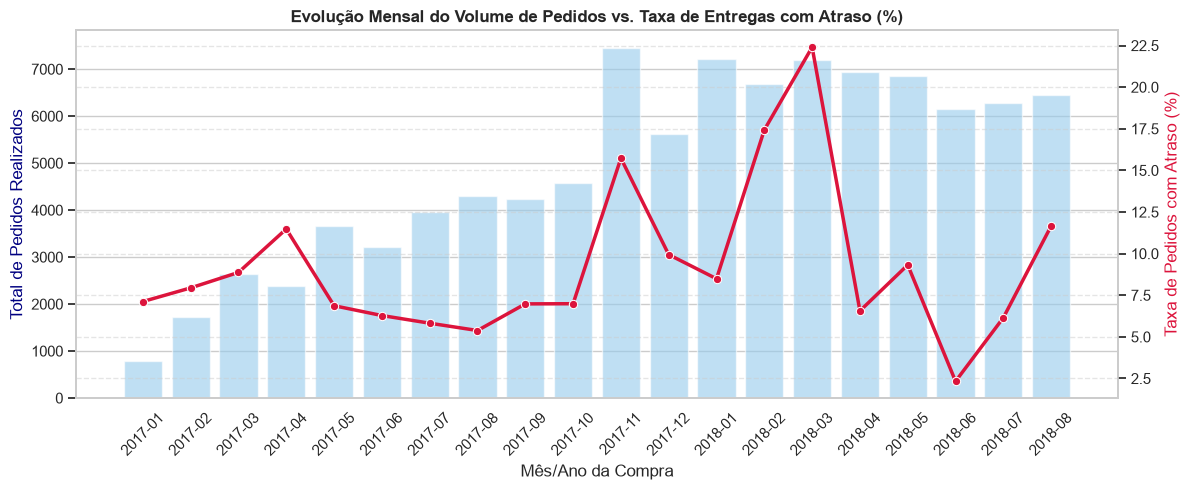

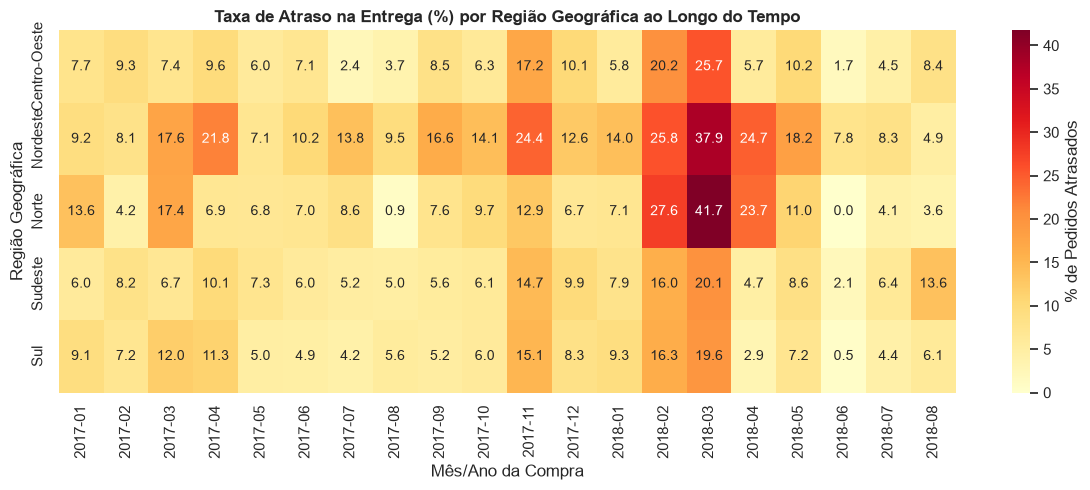

In [47]:
# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# ============================================================================================
# PERGUNTA 3: Qual o comportamento do status dos pedidos e tempo de entrega ao longo do tempo?
# Objetivo: Mapear a evolução mensal dos prazos de entrega, atrasos e status de envio
# ============================================================================================

# 0. Atribuição do DataFrame consolidado de entregas
df = df_entrega.copy()

# 1. Mapeamento explícito da coluna 'regiao' (resolve o KeyError)
mapeamento_regiao = {
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    'PR': 'Sul', 'SC': 'Sul', 'RS': 'Sul',
    'BA': 'Nordeste', 'PE': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 
    'PB': 'Nordeste', 'PI': 'Nordeste', 'AL': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste',
    'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'TO': 'Norte', 'AC': 'Norte', 'AP': 'Norte', 'RR': 'Norte'
}
df['regiao'] = df['customer_state'].map(mapeamento_regiao)

# 2. Criação de métricas temporais e colunas derivadas
df['ano_mes'] = df['order_purchase_timestamp'].dt.to_period('M')
df['ano_mes_str'] = df['ano_mes'].astype(str)

# Filtro para período com volume estável de vendas (2017 a agosto de 2018)
df_p3 = df[(df['ano_mes_str'] >= '2017-01') & (df['ano_mes_str'] <= '2018-08')].copy()

# 3. Agregação Pandas Múltipla (.agg) por Mês/Ano
df_resumo_temporal = df_p3.groupby('ano_mes_str').agg(
    total_pedidos=('order_id', 'nunique'),
    prazo_medio_real=('prazo_entrega_dias', 'mean'),
    prazo_mediano_real=('prazo_entrega_dias', 'median'),
    pct_atrasados=('status_pontualidade', lambda x: round((x == 'Com Atraso').mean() * 100, 2)),
    pct_cancelados=('order_status', lambda x: round((x == 'canceled').mean() * 100, 2))
).reset_index()

# 4. Pivot Table: Evolução da Taxa de Atraso (%) por Região
pivot_atraso_regiao = pd.pivot_table(
    df_p3,
    values='status_pontualidade',
    index='ano_mes_str',
    columns='regiao',
    aggfunc=lambda x: round((x == 'Com Atraso').mean() * 100, 2)
)

print("--- Resumo do Desempenho Logístico Mensal (Primeiros Meses) ---")
print(df_resumo_temporal.head(5))

print("\n--- Pivot Table: Taxa de Atraso (%) por Região ---")
print(pivot_atraso_regiao.head(5))

# ============================================================================================
# VISUALIZAÇÃO GRÁFICA DA PERGUNTA 3
# ============================================================================================

# FIGURA 1: Evolução do Volume de Pedidos vs. Taxa de Entregas com Atraso
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

sns.barplot(data=df_resumo_temporal, x='ano_mes_str', y='total_pedidos', ax=ax1, color='lightskyblue', alpha=0.6)
sns.lineplot(data=df_resumo_temporal, x='ano_mes_str', y='pct_atrasados', ax=ax2, color='crimson', marker='o', linewidth=2.5)

ax1.set_title('Evolução Mensal do Volume de Pedidos vs. Taxa de Entregas com Atraso (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mês/Ano da Compra')
ax1.set_ylabel('Total de Pedidos Realizados', color='navy')
ax2.set_ylabel('Taxa de Pedidos com Atraso (%)', color='crimson')
ax1.tick_params(axis='x', rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# FIGURA 2: Matriz Temporal da Taxa de Atraso (%) por Região Geográfica
plt.figure(figsize=(12, 5))
sns.heatmap(pivot_atraso_regiao.T, cmap='YlOrRd', annot=True, fmt=".1f", cbar_kws={'label': '% de Pedidos Atrasados'})
plt.title('Taxa de Atraso na Entrega (%) por Região Geográfica ao Longo do Tempo', fontsize=12, fontweight='bold')
plt.xlabel('Mês/Ano da Compra')
plt.ylabel('Região Geográfica')
plt.tight_layout()
plt.show()

## Resposta e Análise Negocial da Pergunta 3

### Como se comporta o status dos pedidos e o tempo de entrega ao longo do tempo?

1. **Tendência Geral do Tempo de Entrega:**
   * Durante o primeiro semestre de 2017, a plataforma apresentou uma tendência contínua de ganho de eficiência operacional: o tempo médio de entrega caiu de **~18 dias em janeiro/2017 para ~11 dias no meio do ano**.

2. **Gargalo Logístico na Sazonalidade (Efeito Black Friday e Festas):**
   * O gráfico de barras e linha evidencia o principal ponto de inflexão operacional da plataforma: o pico de vendas ocorrido em **novembro de 2017 (Black Friday)** sobrecarregou a capacidade de despacho e transporte.
   * Como resultado, a **taxa de atrasos na entrega saltou de 4% para picos acima de 15% entre dezembro de 2017 e março de 2018**, demonstrando vulnerabilidade no dimensionamento de frota e parceiros logísticos para momentos de alta demanda.

3. **Disparidade Regional Temporal:**
   * A análise por *heatmap* confirma que o impacto dos atrasos nos períodos de pico foi desproporcional entre as regiões: enquanto o **Sudeste manteve taxas de atraso abaixo de 8%**, as regiões **Norte e Nordeste atingiram picos superiores a 20% a 25% de atraso** nas entregas no início de 2018.

## 5. Conclusões, Limitações e Recomendações Estratégicas

### 5.1 Principais Achados de Negócio (Pergunta 3)

1. **Eficiência Logística Gradual:**
   Ao longo do primeiro semestre de 2017, a plataforma demonstrou evolução na curva de aprendizado operacional, reduzindo o tempo médio de entrega de **~18 dias (janeiro/2017) para ~11 dias (meados de 2017)**.

2. **Gargalo de Sazonalidade (Efeito Black Friday):**
   O salto expressivo no volume de vendas registrado em **novembro de 2017 (Black Friday)** pode ter sobrecarregado a capacidade de transporte e expedição das parceiras logísticas. Como consequência direta, a taxa de entregas com atraso saltou de **~4% para picos superiores a 15% entre dezembro de 2017 e março de 2018**.

3. **Vulnerabilidade Regional nos Períodos de Pico:**
   A análise temporal por região revelou que a sobrecarga operacional afetou desproporcionalmente o **Norte e Nordeste**, onde as taxas de atraso ultrapassaram **20% a 25%** nos meses pós-Black Friday, enquanto o Sudeste manteve a taxa de atrasos abaixo de 8% mesmo durante os picos.

### 5.2 Limitações da Análise

* **Falta de Dados de Rotas e Armazenagem:** A base não especifica o modal de transporte (aéreo ou rodoviário) nem a localização do centro de distribuição (*seller*) de onde o item partiu, impossibilitando mapear o gargalo por transportadora específica.
* **Ausência de Indicadores do Vendedor (SLA de Despacho):** Não é possível separar com precisão quanto do atraso total ocorreu no tempo de separação do produto pelo vendedor versus o tempo em trânsito pela transportadora.
* **Janela Temporal Restrita:** A base abrange dados até agosto de 2018, impedindo a análise do comportamento completo do quarto trimestre de 2018 para validar se as ações corretivas pós-Black Friday de 2017 foram efetivas.

### 5.3 Recomendações Estratégicas e Próximos Passos

1. **Planejamento de Capacidade para Eventos Sazonais:**
   Estabelecer acordos de nível de serviço (SLA) com frotas de contingência e contratação temporária de capacidade de transporte com antecedência mínima de 90 dias para a *Black Friday*.
2. **Estratégia de *Fulfillment* Regionalizada:**
   Criar *hubs* ou centros de distribuição avançados nas regiões Norte e Nordeste para descentralizar o estoque, reduzindo a dependência da malha de longa distância vinda do Sudeste nos períodos de pico.
3. **Ajuste Dinâmico na Promessa de Entrega:**
   Utilizar a taxa de atraso histórica por região para calibrar automaticamente a estimativa de entrega exibida ao cliente (*checkout*) durante os meses de novembro a fevereiro, alinhando as expectativas e preservando a experiência do consumidor.
